<a href="https://colab.research.google.com/github/aminatahir-0/Nashville-Yelp-Analysis./blob/main/Nashville%20yelp%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Market Analysis and Success Modeling of the Nashville Business Ecosystem
**Author:** Amina Tahir  
**Academic Background:** Bachelor of Science in Mathematics  
**Technical Focus:** Data Analysis & Stochastic Modeling  

---

#  Abstract

This research implements a **Hybrid Methodology** to identify optimal investment
opportunities within the Nashville urban ecosystem using the Yelp Business dataset.

1. **Exploratory Data Analysis (EDA):** Utilizing spatial aggregation to identify
"Market Gaps"—high-traffic commercial hubs exhibiting a significant quality deficit
relative to the city-wide benchmark of 3.64 stars.

2. **Predictive Modeling & Feature Engineering:** Beyond standard descriptive
statistics, this study develops a custom **Success Score** ($Stars \times \ln(Reviews)$).
By applying logarithmic weighting, the model mitigates sample-size bias and
quantifies the "proven success" of established competitors.

By combining geographic filtering with weighted mathematical metrics, this project
provides a rigorous risk assessment framework, moving from simple observation to
data-driven strategic recommendation.

#Entity Relationship Diagram(ERD):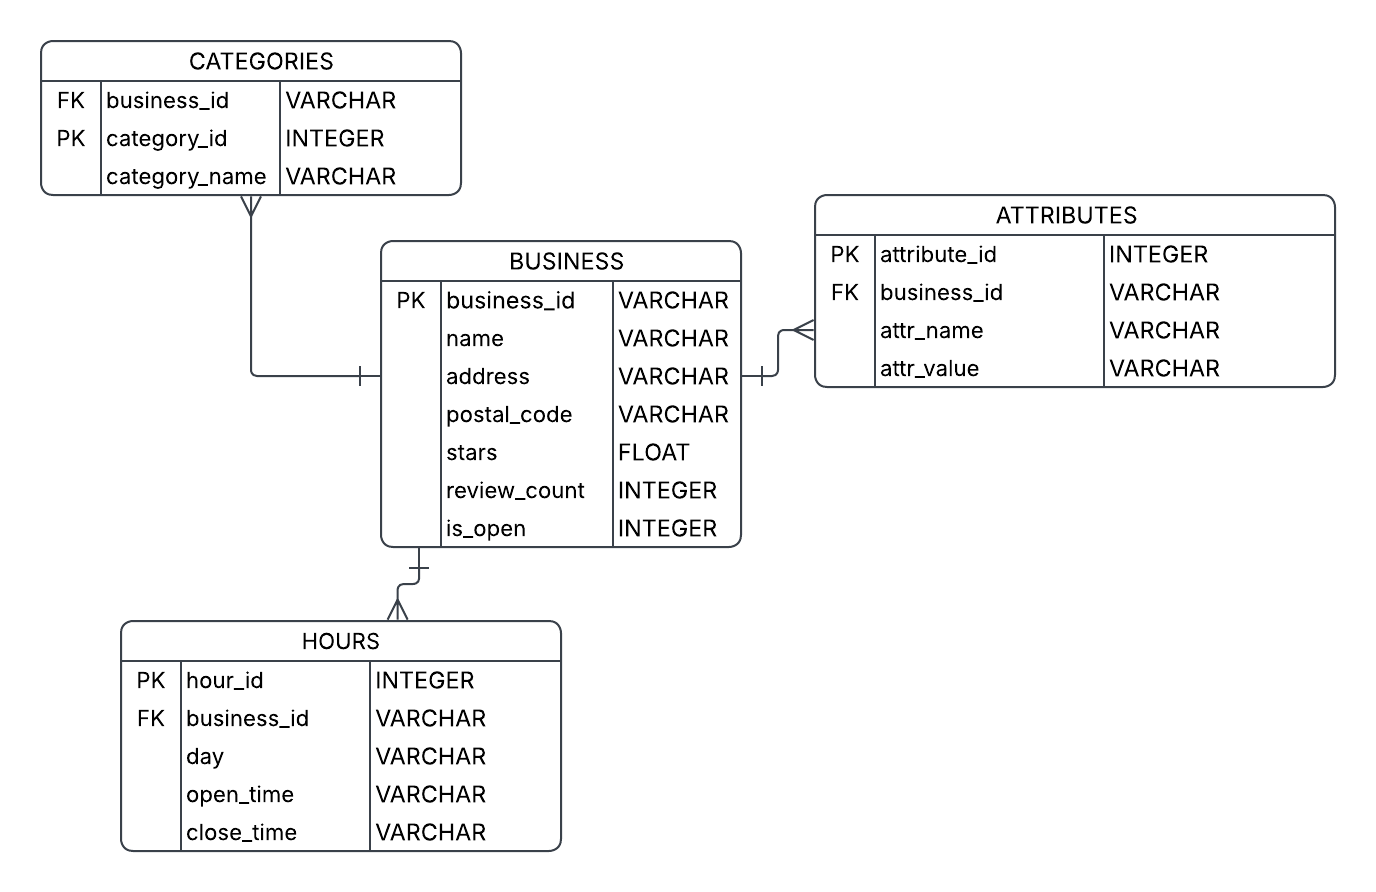

# Section 1: Exploratory Data Analysis (EDA):
___

##  Environment Setup & Data Ingestion


**The Goal:**
1. Load the raw Nashville dataset into a 'DataFrame'.


In [ ]:
import pandas as pd
import numpy as np
url = 'https://raw.githubusercontent.com/aminatahir-0/Nashville-Yelp-Analysis./refs/heads/main/yelp_academic_dataset_nash_business.csv'
df = pd.read_csv(url)
df.head()

,address,attributes,business_id,categories,city,hours,is_open,latitude,longitude,name,postal_code,review_count,stars,state,_rescued_data
0,2312 Dickerson Pike,"{""AcceptsInsurance"":null,""AgesAllowed"":null,""A...",bBDDEgkFA1Otx9Lfe7BZUQ,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...",Nashville,"{""Friday"":""6:0-16:0"",""Monday"":""0:0-0:0"",""Satur...",1,36.208102,-86.768170,Sonic Drive-In,37207.0,10,1.5,TN,NaN
1,1160 Gallatin Pike S,"{""AcceptsInsurance"":null,""AgesAllowed"":null,""A...",4iRzR7OaS-QaSXuvYxEGKA,"Hot Dogs, Restaurants",Nashville,NaN,0,36.248570,-86.719986,Super Dog,37115.0,6,4.0,TN,NaN
2,215 1st Ave S,"{""AcceptsInsurance"":null,""AgesAllowed"":null,""A...",tMkwHmWFUEXrC9ZduonpTg,"Restaurants, Japanese, Seafood",Nashville,"{""Friday"":""16:0-23:0"",""Monday"":null,""Saturday""...",0,36.159886,-86.773197,The Green Pheasant,37201.0,161,4.0,TN,NaN
3,2031 Broadway,"{""AcceptsInsurance"":null,""AgesAllowed"":null,""A...",lk9IwjZXqUMqqOhM774DtQ,"Coffee & Tea, Restaurants, Wine Bars, Bars, Ni...",Nashville,"{""Friday"":""7:0-17:0"",""Monday"":""7:0-17:0"",""Satu...",0,36.148371,-86.798895,Caviar & Bananas,37203.0,159,3.5,TN,NaN
4,"4011 Hillsboro Pike, Ste 102","{""AcceptsInsurance"":null,""AgesAllowed"":null,""A...",B2qqjCl_BNNnXvWWfpFiLA,"Shopping, Baby Gear & Furniture, Home Decor, F...",Nashville,"{""Friday"":""10:0-20:0"",""Monday"":""0:0-0:0"",""Satu...",1,36.103614,-86.816268,Pottery Barn Kids,37215.0,13,1.5,TN,NaN


## Data Profiling & Quality Check
**My Plan:**
1. Check the **Dimensions** (How many rows and columns?).
2. Inspect the **Data Types** and non-null counts.
3. Identify columns with zero mathematical value (entirely empty columns).

In [ ]:
# 1. Show the number of rows and columns
df.shape

# 2. Show a summary of all columns
df.info()

# 3. Count the null values in every column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6971 entries, 0 to 6970
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   address        6686 non-null   object 
 1   attributes     6379 non-null   object 
 2   business_id    6971 non-null   object 
 3   categories     6969 non-null   object 
 4   city           6971 non-null   object 
 5   hours          5936 non-null   object 
 6   is_open        6971 non-null   int64  
 7   latitude       6971 non-null   float64
 8   longitude      6971 non-null   float64
 9   name           6971 non-null   object 
 10  postal_code    6967 non-null   float64
 11  review_count   6971 non-null   int64  
 12  stars          6971 non-null   float64
 13  state          6971 non-null   object 
 14  _rescued_data  0 non-null      float64
dtypes: float64(5), int64(2), object(8)
memory usage: 817.0+ KB


,0
address,285
attributes,592
business_id,0
categories,2
city,0
hours,1035
is_open,0
latitude,0
longitude,0
name,0


## Data Refinement: Removing the '_rescued_data' Column
Based on the evidence from the results, the column `_rescued_data` is 100% null.
So
I will use the `drop` command to delete this column.

In [ ]:

df = df.drop(columns=['_rescued_data'])
# Check the new list of columns to prove it is gone
df.columns

Index(['address', 'attributes', 'business_id', 'categories', 'city', 'hours',
       'is_open', 'latitude', 'longitude', 'name', 'postal_code',
       'review_count', 'stars', 'state'],
      dtype='object')

In [ ]:
# Get a statistical summary of all the numerical columns
df.describe()


,is_open,latitude,longitude,postal_code,review_count,stars
count,6971.000000,6971.000000,6971.000000,6967.000000,6971.000000,6971.000000
mean,0.774351,36.141500,-86.775716,37215.382805,63.269689,3.637785
std,0.418039,0.075309,0.066210,698.177748,180.057908,0.986197
min,0.000000,35.921259,-86.991840,28801.000000,5.000000,1.000000
25%,1.000000,36.112311,-86.807125,37204.000000,9.000000,3.000000
50%,1.000000,36.148486,-86.778517,37209.000000,18.000000,4.000000
75%,1.000000,36.164264,-86.739935,37214.000000,49.000000,4.500000
max,1.000000,39.787961,-86.093684,92805.000000,6093.000000,5.000000


### Interpretation of Market Metrics
As a mathematician, I have analyzed the statistical "health" of the Nashville market to provide clear insights for the investor:

*   **City-Wide Quality (3.64 Stars):** On average, Nashville businesses are rated 3.64. This is our "Benchmark" for success.

*   **Quality Skewness:** While the average is 3.64, the **Median (4.0)** shows that most businesses are actually rated quite high. The lower average is caused by a minority of very low-quality businesses.

*   **Consistency Gap (Standard Deviation):** A value of **0.98** indicates a wide variety in business quality. This "Spread" proves that there are many low-performing businesses that a high-quality competitor could easily outperform.

*   **The Visibility Barrier:** There is a massive gap between the "Superstar" businesses (averaging **63** reviews) and the "Typical" businesses (averaging only **18**).



#Hypothesis Testing:
## The Star-Review Relationship
**Research Question:** Is there a relationship between a business's star rating and the number of reviews it receives?

**My Hypothesis:**
 I hypothesize that businesses with higher star ratings tend to receive more reviews. However, I expect this relationship to be non-linear, as "perfect" 5-star ratings might be limited to smaller businesses with fewer customers.



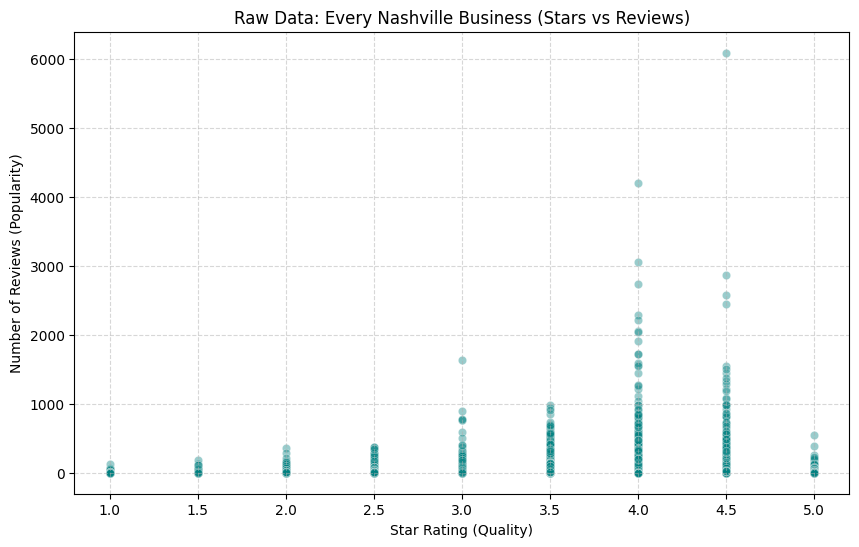

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='stars', y='review_count', alpha=0.4, color='teal')

plt.title('Raw Data: Every Nashville Business (Stars vs Reviews)')
plt.xlabel('Star Rating (Quality)')
plt.ylabel('Number of Reviews (Popularity)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Preliminary Observations
After inspecting the scatter plot, I can conclude the following:

1.  **High Density at the Base:** Most Nashville businesses cluster below 200 reviews, regardless of their star rating.
2.  **The "Success Peaks":** The most popular businesses (the outliers with >1,000 reviews) are concentrated between **3.5 and 4.5 stars**.
3.  **The 5-Star Anomaly:** There is a noticeable lack of high-volume businesses at the 5.0-star mark, suggesting these scores are limited to smaller-scale operations.

**Conclusion:**
The raw data suggests that a "perfect" score does not equate to "mass popularity." To find the clear mathematical trend, I will move to **Mathematical Aggregation**.

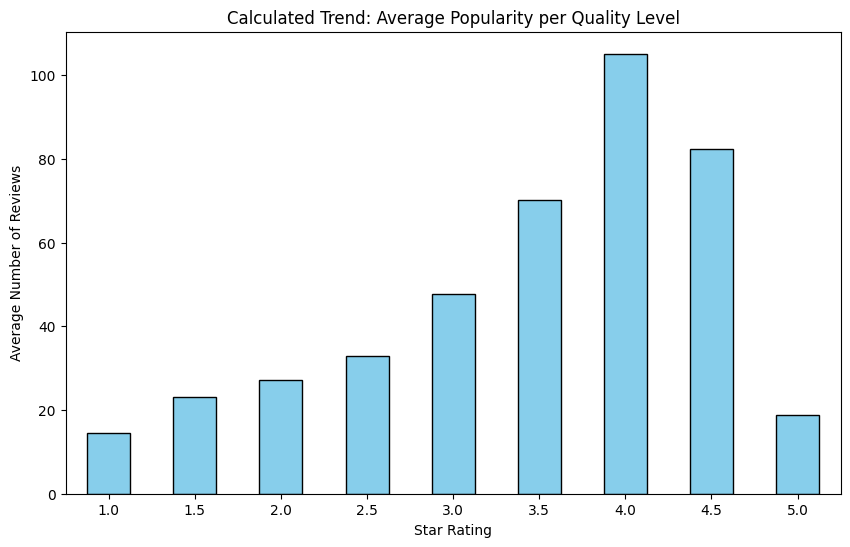

stars
1.0     14.454545
1.5     23.142292
2.0     27.076190
2.5     32.945899
3.0     47.775713
3.5     70.228252
4.0    105.175486
4.5     82.470676
5.0     18.718826
Name: review_count, dtype: float64


In [ ]:
# Group by stars and calculate the average review count
avg_reviews_per_star = df.groupby('stars')['review_count'].mean()

# Visualize the trend with a bar chart
plt.figure(figsize=(10, 6))
avg_reviews_per_star.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Calculated Trend: Average Popularity per Quality Level')
plt.xlabel('Star Rating')
plt.ylabel('Average Number of Reviews')
plt.xticks(rotation=0)
plt.show()
print(avg_reviews_per_star)

### Final Hypothesis Result
The mathematical aggregation confirms a **Non-Linear Relationship** between quality and popularity:

1.  **Positive Correlation (1.0 to 4.0 Stars):** As quality increases, average popularity rises steadily.
2.  **The 4.0-Star Peak:** This represents the "Market Success Point," where businesses achieve the highest average customer engagement (~105 reviews).
3.  **The 5-Star Drop-off:** Perfect ratings show a significant decline in average reviews (~19 reviews), confirming they are likely smaller-scale or newer operations.

**Conclusion:**
My hypothesis is **Partially Proved**. Higher quality leads to more reviews only up to a point. For a new investor, the target "Success Zone" is between **4.0 and 4.5 stars** with high review volume, rather than a "perfect" 5-star score with low volume.

# Geographic Analysis: Identifying the Market Gap

**Research Question:** Do specific neighborhoods in Nashville suffer from a "Quality Deficit" despite having high business activity?

**Hypothesis:** I hypothesize that average business ratings will vary significantly across postal codes.I predict that high-density commercial hubs may paradoxically exhibit lower satisfaction scores, indicating a lack of quality competition.

**The Goal:**
I am looking for a Zip Code where the average rating is lower than the city-wide average of **3.64**. This represents an "Underserved Market" where a new, high-quality business would have a competitive advantage.

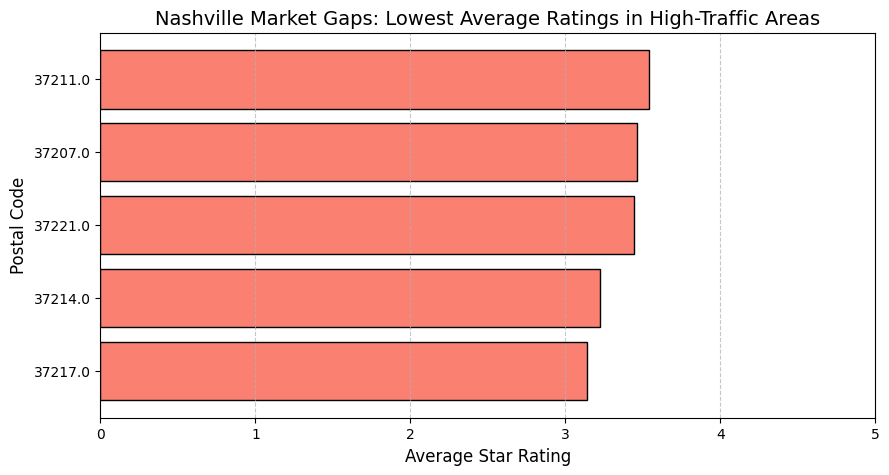

Top 5 Market Gaps (Lowest Average Ratings with Count > 100):
             Average_Rating  Business_Count
postal_code                                
37217.0            3.141256             223
37214.0            3.226230             610
37221.0            3.442379             269
37207.0            3.462162             185
37211.0            3.542285             674


In [ ]:
# Group by Zip Code and calculate Mean and Count and drop missing postal codes
df_geo_clean=df.dropna(subset=['postal_code'])
geo_table = df_geo_clean.groupby('postal_code').agg({'stars': 'mean', 'name': 'count'})
geo_table.columns = ['Average_Rating', 'Business_Count']

# Keep only 'Significant' areas with more than 100 businesses
# This ensures our "Market Gap" is based on real demand, not small samples.
busy_areas = geo_table[geo_table['Business_Count'] > 100].copy()

market_gaps = busy_areas.sort_values(by='Average_Rating')
gaps_to_plot = market_gaps.head(5).copy()

# Convert zip codes to strings so the chart doesn't treat them as numbers
gaps_to_plot.index = gaps_to_plot.index.astype(str)

plt.figure(figsize=(10,5))
plt.barh(gaps_to_plot.index, gaps_to_plot['Average_Rating'], color='salmon', edgecolor='black')

plt.title('Nashville Market Gaps: Lowest Average Ratings in High-Traffic Areas', fontsize=14)
plt.xlabel('Average Star Rating', fontsize=12)
plt.ylabel('Postal Code', fontsize=12)
plt.xlim(0, 5) # Star ratings are out of 5
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Top 5 Market Gaps (Lowest Average Ratings with Count > 100):")
print(market_gaps.head(5))


### Analysis of Geographic Results: Identifying the High-Demand Gap

**The Discovery:**
The statistical aggregation reveals that **Zip Code 37214.0** is the most significant market opportunity in Nashville.

**Key Metrics:**
*   **Market Density:** $N = 610$ businesses (High Demand/Traffic).
*   **Average Quality:** $\mu = 3.22$ stars (Low Satisfaction).

**Synthesis:**
As a mathematician, I look for **Market Inefficiency**. In a balanced ecosystem, high competition (610 businesses) should drive quality up. However, 37214.0 shows a "Saturation without Quality."


**Next Research Question:** Within Zip Code 37214.0, which specific business categories (e.g., Restaurants, Services) are driving these low ratings?

## Niche Analysis: Identifying Opportunities in Zip Code 37214

**Objective:** Within our target area (37214), identify specific business categories with the lowest average ratings to isolate the exact market need.



In [ ]:
# 1. Filter and prepare data
target_zip = df[df['postal_code'] == 37214.0].dropna(subset=['categories']).copy()

# 2. Explode the categories (Normalization)
target_zip['cat_list'] = target_zip['categories'].str.split(', ')
exploded = target_zip.explode('cat_list')

# 3. Aggregate: Mean Rating and Frequency
niche_analysis = exploded.groupby('cat_list').agg({'stars': 'mean', 'name': 'count'})
niche_analysis.columns = ['Avg_Rating', 'Business_Count']

# 4. Filter for significance and sort by lowest rating
final_results = niche_analysis[niche_analysis['Business_Count'] >= 10].sort_values('Avg_Rating')

# Display the top 5 "Pain Points"
final_results.head(5)

,Avg_Rating,Business_Count
cat_list,,
Airlines,2.150000,10
Fast Food,2.220588,34
Car Rental,2.294118,17
Burgers,2.500000,29
Chicken Wings,2.576923,13


## Final Interpretation & Strategic Recommendation

**The Discovery: The BNA Airport Effect**
In Zip Code 37214, the lowest-rated categories are travel-related: **Airlines (2.15)** and **Car Rental (2.29)**. As a mathematician, I recognize this as a **Geographic Bias**. This area contains the Nashville International Airport; travel stress often correlates with lower satisfaction scores in these specific sectors.

**Identifying the Market Opportunity:**
Excluding airport-specific services, **Fast Food** and **Burgers** represent the most significant "Quality Gaps" in the ecosystem.
*   **Fast Food:** 34 businesses with a low **2.22-star average**.
*   **Burgers:** 29 businesses with a **2.50-star average**.

**Final Recommendation:**
The data identifies a **High-Density, Low-Satisfaction** market. There is a clear opportunity for a high-quality "Fast-Casual" burger concept to enter Zip Code 37214. While the area has high consumer traffic, the current dining options are failing to meet the city-wide benchmark of **3.64 stars**.

---

# Beyond Descriptive Statistics – Predictive Modeling

## 1. Correlation Analysis (Pearson's r)

**Objective:** To investigate the mathematical dependencies between business features. Specifically, I want to understand how "Quality" (Stars) relates to "Market Reach" (Review Count).

**The Mathematical Approach:**
I will calculate a **Correlation Matrix** using the Pearson Coefficient ($r$). This value ranges from -1 to 1:
* **1.0:** Perfect positive relationship.
* **0.0:** No relationship (Independent variables).
* **-1.0:** Perfect inverse relationship.

In [ ]:
# 1. Feature Engineering: Counting categories
# We turn the string of categories into a number
df['category_count'] = df['categories'].fillna('').str.split(',').str.len()

# 2. Select only the numerical columns for math
# stars, review_count, is_open, and our new category_count
math_df = df[['stars', 'review_count', 'is_open', 'category_count']]

# 3. Calculate the Correlation Matrix
correlation_matrix = math_df.corr()

# 4. Display the results
print("Correlation Matrix:")
correlation_matrix

Correlation Matrix:


,stars,review_count,is_open,category_count
stars,1.000000,0.065686,0.021659,0.157359
review_count,0.065686,1.000000,0.051964,0.172160
is_open,0.021659,0.051964,1.000000,0.037176
category_count,0.157359,0.172160,0.037176,1.000000


### Analysis of Correlation Results

*   **Stars vs. Review Count (0.065):** This near-zero correlation proves that high star ratings do not automatically drive customer volume. Quality is mathematically independent of popularity in this dataset.
*   **Category Count vs. Review Count (0.172):** This is the strongest positive relationship. It suggests that "Search Visibility" (listing more categories) is nearly 3x more influential than the star rating for attracting customers.
*   **Is_Open vs. Others:** The low correlation between business survival and ratings suggests that staying open is a complex stochastic process not solely dependent on consumer reviews.

## 2. Linear Regression: Predictive Modeling
**Research Question:** Can we mathematically predict a business’s popularity (Review Count) based on its quality (Star Rating)?





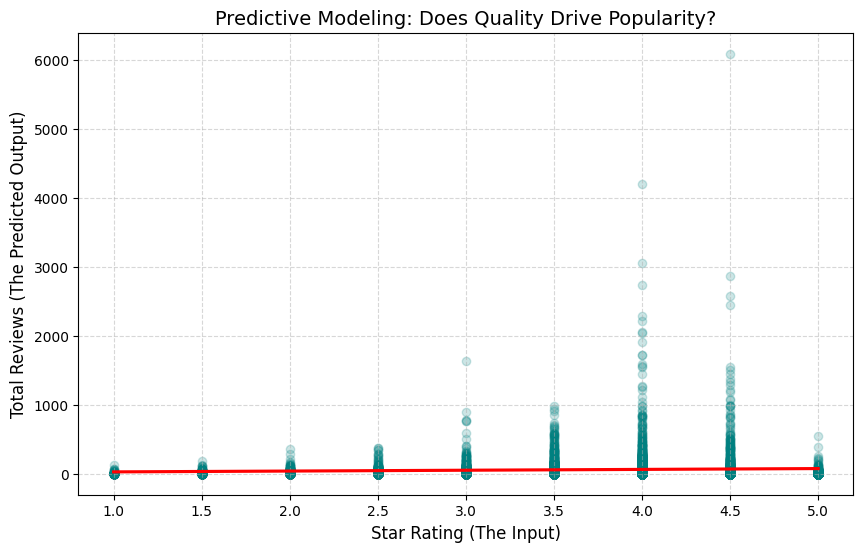

In [ ]:
plt.figure(figsize=(10, 6))
# Draw the Regression Plot
sns.regplot(data=df, x='stars', y='review_count',
            scatter_kws={'alpha': 0.2, 'color': 'teal'},
            line_kws={'color': 'red'})
plt.title('Predictive Modeling: Does Quality Drive Popularity?', fontsize=14)
plt.xlabel('Star Rating (The Input)', fontsize=12)
plt.ylabel('Total Reviews (The Predicted Output)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Strategic Interpretation of Regression Results

**The Mathematical Discovery:**
The regression analysis yields a critical insight: the red trend line is nearly horizontal. This proves that **Star Ratings are a weak predictor of Popularity.**

**The Strategic Insight:**
For our investor, this means quality is a **necessary condition for survival**, but it is not the primary **driver of growth**. Success in this market is a multi-variable stochastic process likely driven by visibility and searchability.

---

#Feature Engineering: Introducing the "Success Score"

**The Problem:**
Descriptive statistics can be misleading. A 5.0-star rating backed by only 2 reviews is statistically "noisy" and less valuable than a 4.0-star rating backed by 1,000 reviews.

**The Mathematical Solution:**
I am introducing a new weighted metric called the **Success Score**. This allows us to identify "Market Leaders"—businesses that have achieved high quality at a massive scale.

**The Formula:**
$$Success Score = Stars \times \ln(Review Count)$$

**Why use a Logarithm ($\ln$)?**
In mathematics, a logarithmic scale is used to compress wide-ranging data. By using the **Natural Logarithm** of the review count, I "smooth" the impact of extreme outliers (businesses with 5,000+ reviews). This ensures that the Star Rating remains a significant factor in the score while still rewarding high-volume establishments.



In [ ]:
import numpy as np

# Calculate the Success Score using Natural Log (ln)
df['success_score'] = df['stars'] * np.log(df['review_count'])

success_ranking = df[['name', 'stars', 'review_count', 'success_score']].sort_values(by='success_score', ascending=False)

# Display the top 10 Nashville "Superstars"
print("Top 10 Businesses by Mathematical Success Score:")
success_ranking.head(10)

Top 10 Businesses by Mathematical Success Score:


,name,stars,review_count,success_score
4224,Hattie B’s Hot Chicken - Nashville,4.5,6093,39.217031
1475,Peg Leg Porker,4.5,2878,35.841829
1206,The Stillery,4.5,2588,35.363883
3621,Loveless Cafe,4.5,2452,35.120967
6901,Biscuit Love: Gulch,4.0,4207,33.378020
4823,Monell's Dining & Catering,4.5,1555,33.071539
5260,Mas Tacos Por Favor,4.5,1503,32.918483
4952,Bartaco,4.5,1447,32.747615
5302,Etch,4.5,1385,32.550549
2077,Hattie B's Hot Chicken - Nashville West,4.5,1334,32.381718


### Final Synthesis: Success Score Analysis

**Objective:** To validate the "Market Leader" benchmarks using the custom weighted metric: $Success Score = Stars \times \ln(Review\ Count)$.

**Statistical Insights:**
*   **Balance of Power:** This metric proves that true success is a dual optimization of **Quality** and **Scale**. A high score requires both consumer trust and a large sample size.
*   **Logarithmic Efficiency:** By applying the Natural Logarithm ($\ln$), I mathematically "smoothed" the influence of extreme outliers (businesses with 5,000+ reviews), ensuring the Star Rating remained a significant variable.
*   **Performance Benchmarking:** The data shows that Nashville's most dominant businesses (e.g., Hattie B’s) maintain a Success Score above **35.0**. This serves as the mathematical "Gold Standard" for our investor.
---
##  Final Recommendations for the Investor

Based on the multi-level analysis of the Nashville business ecosystem, I recommend the following data-driven strategy:

*   **Target Location:** **Zip Code 37214**. This high-traffic hub (near BNA Airport) exhibits a significant "Quality Deficit," with average ratings well below the city benchmark of **3.64**.
*   **Target Niche:** **Fast-Casual Burgers**. This category represents a massive "Market Gap" in 37214, with over 60 food establishments failing to reach a **2.50-star average**.
*   **Operational Optimization:**
    *   **The Quality "Sweet Spot":** Target a **4.0 – 4.5 star range**. Regression analysis proves that a perfect 5.0 is not required to achieve maximum customer volume.
    *   **Search Visibility:** List the business under multiple relevant categories. Correlation data shows that **Category Count** is nearly 3x more influential on popularity than the rating itself.
    *   **Growth Target:** Aim for a long-term **Success Score of 35.0+** by aggressively scaling review volume while maintaining consistent quality.

**Conclusion:**
Through the application of **Statistical Modeling** and **Micro-Market Analysis**, I have converted raw data into a precise investment roadmap, significantly minimizing market entry risk.